# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

# Simulating data

## Single df

### Creating

In [96]:
((20-5)+1) * ((9-5) +1) - (16 - 11)

75

In [2]:
dict_of_combs = {
    
    
    's_5_20_5_9_16_80': [5,20,5,9,16],

    's_13_28_5_9_16_80': [13,28,5,9,16],

    's_19_34_5_9_16_80': [19,34,5,9,16],
                 }

In [124]:
dict_of_combs = {

    'a': [12,10,4,6,4,5, None],
    'b': [16,10,4,7,4,5,None],
    'c': [20,10,4,8,4,5,None],
    'd': [20,12,4,7,4,6,None],
    'e': [20,14,4,7,4,7,2],
    
    'f': [20,16,4,7,4,7,None],
    'g': [20,18,4,8,4,7,3],
    'h': [20,20,4,8,4,7,None],
    'i': [22,20,4,9,4,7,4],
    'j': [24,20,4,9,4,7,6],
    'j': [26,20,4,10,4,7,5],

    'k': [28,20,4,11,4,7,4],
    'l': [30,20,4,13,4,6,None],
    'm': [32,20,4,13,4,7,2],
    'n': [34,20,4,13,4,7,4],
    'o': [36,20,4,13,4,7,6],

    'p': [38,20,4,13,4,7,8],
    'q': [40,20,4,13,4,7,10],
}

In [125]:
i = 'q'
gdf_output = return_spatial_geo_df(

    n_x = dict_of_combs[i][0],  
    n_y = dict_of_combs[i][1],    
    spacing = 100, 

    treated_scope_x_start = dict_of_combs[i][2],
    treated_scope_x_end = dict_of_combs[i][3],
    treated_scope_y_start = dict_of_combs[i][4],
    treated_scope_y_end = dict_of_combs[i][5],
    treated_last_row_length = dict_of_combs[i][6],
   
    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 2,
    y_spatial_autocorelation_scope_x_end = 10,
    y_spatial_autocorelation_scope_y_start = 2,
    y_spatial_autocorelation_scope_y_end = 10,

    rho = 0.15,

    spatial_confounder_scope_x_start = 0,
    spatial_confounder_scope_x_end = 0,
    spatial_confounder_scope_y_start = 0,
    spatial_confounder_scope_y_end = 0,
    

    lambda_cs = 0.0,
    max_treatment_spillover_distance = 300,
    understimated_treatment_spillover_distance=None,
    overestimated_treatment_spillover_distance=None,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)
print(len(gdf_output[gdf_output['T'] == 1]), len(gdf_output))#len(gdf_output[gdf_output['T_tot'] == 1]), len(gdf_output[gdf_output['T_tot'] == 0]))

40 800


#### logic checks

In [28]:
gdf_output.isna().any().any()

np.False_

In [29]:
gdf_output[gdf_output['ODR_1'] == 1][['tau',
 'tau_base']]

,tau,tau_base
34,0.428669,0.509634
35,0.132365,0.157365
43,1.261727,1.500037
46,1.205150,1.432773
53,1.053261,1.252196
56,0.612086,0.727694
63,1.638281,1.947712
66,1.176451,1.398654
74,1.499631,1.782874
75,0.847814,1.007945


In [30]:
gdf_output[gdf_output['T']==1][['unit_id', 'Y_dep_var',
    'T','ODR_1',
    'ODR_2',
    'ODR_3',
    'ODR_4', 'Cont_T_N',]]

KeyError: "['ODR_4'] not in index"

#### Numerical checks

In [31]:
gdf_output[gdf_output['ODR_4']!=0][['unit_id','geometry', 'T_tot','T_tot_cat','T_tot_cat_underestim','T_tot_cat_overerestim', 'ODR_4']]

KeyError: 'ODR_4'

In [ ]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [ ]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.688906747874262)

In [ ]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.5000000000000004)

In [ ]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,...,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y_dep_var,Y_dep_var_ns
385,1385,POINT (1900 500),1900,500,1,-0.064134,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.012997,-0.547858,1.588349,1.192276,1.192276,1.0,0.0,1.0,1.940885,1.491975
386,1386,POINT (1900 600),1900,600,1,1.570982,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.128203,0.515128,0.753198,1.451056,1.451056,1.0,0.0,1.0,2.429891,2.044485
387,1387,POINT (1900 700),1900,700,1,2.410774,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.650723,2.600196,1.828985,1.477928,1.477928,1.0,0.0,1.0,4.386767,4.208832
388,1388,POINT (1900 800),1900,800,1,-2.161792,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.748969,1.501584,-2.391295,1.644746,1.644746,1.0,0.0,1.0,0.665765,0.289349
389,1389,POINT (1900 900),1900,900,1,1.076641,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.312545,0.718879,0.046870,2.060198,2.060198,1.0,0.0,1.0,3.529670,3.302791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1685,POINT (3400 500),3400,500,1,3.179975,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.242619,0.566396,1.763284,1.605507,1.605507,1.0,0.0,1.0,3.860068,3.860068
686,1686,POINT (3400 600),3400,600,1,0.000304,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.349183,-1.174540,1.165104,1.405771,1.405771,1.0,0.0,1.0,0.787989,0.787989
687,1687,POINT (3400 700),3400,700,1,3.145305,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.270506,0.795911,0.528056,1.596711,1.596711,1.0,0.0,1.0,3.066862,3.066862
688,1688,POINT (3400 800),3400,800,1,0.570642,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.511625,0.192774,-0.438668,2.165175,2.165175,1.0,0.0,1.0,3.208426,3.208426


In [ ]:
gdf_output.isna().any().any()

np.False_

In [ ]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y_dep_var'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.1449', 'p-value simulated: 0.0010']

#### Visual checks

<Axes: >

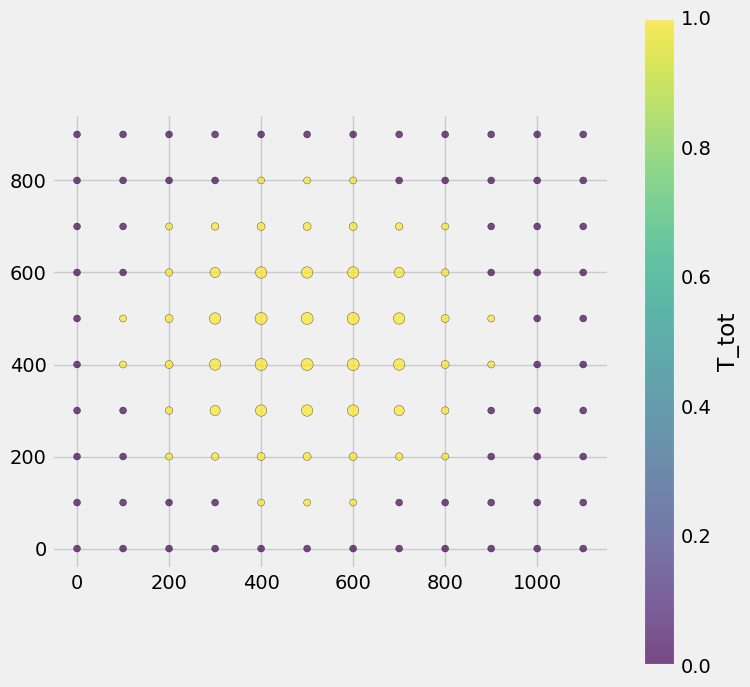

In [32]:

gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

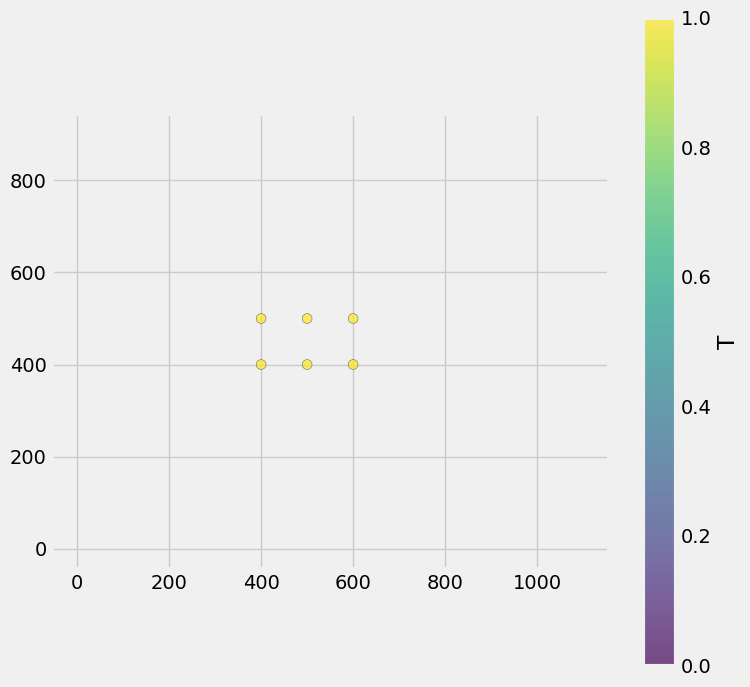

In [33]:
plot_gdf_points(gdf_output3, size_col='T',
    color_col='T')

<Axes: >

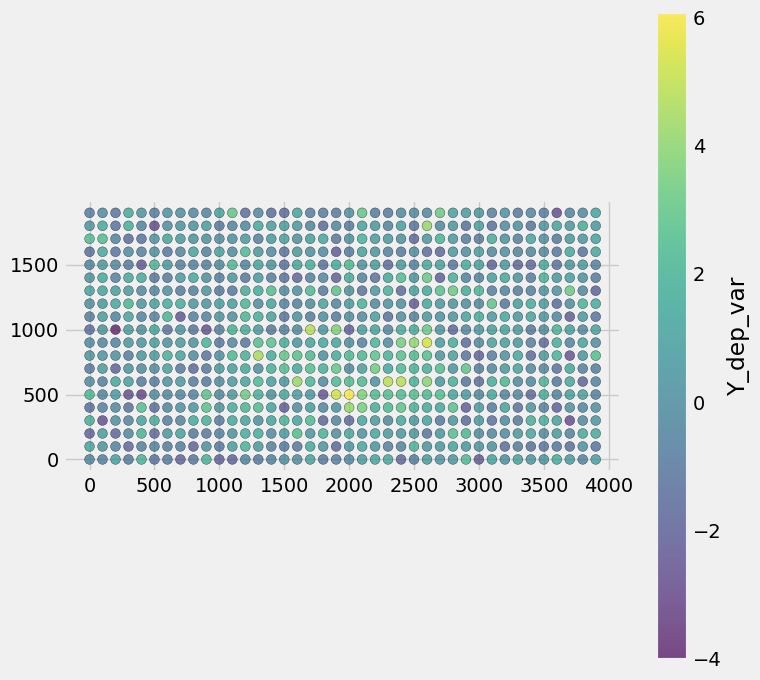

In [19]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y_dep_var')

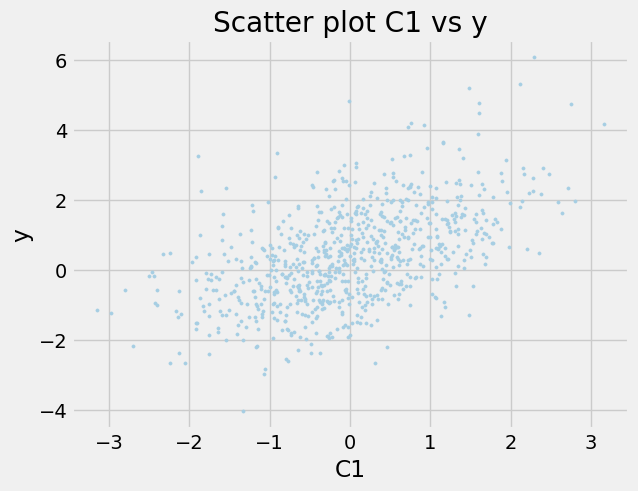

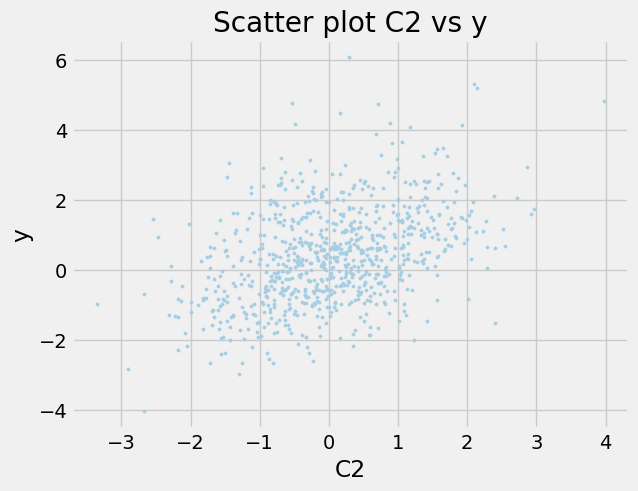

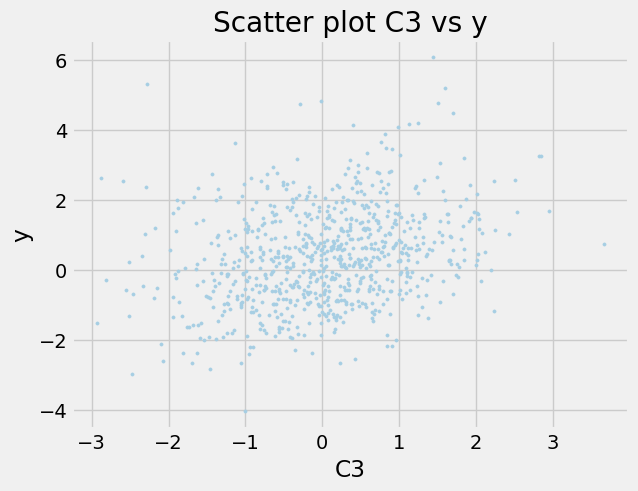

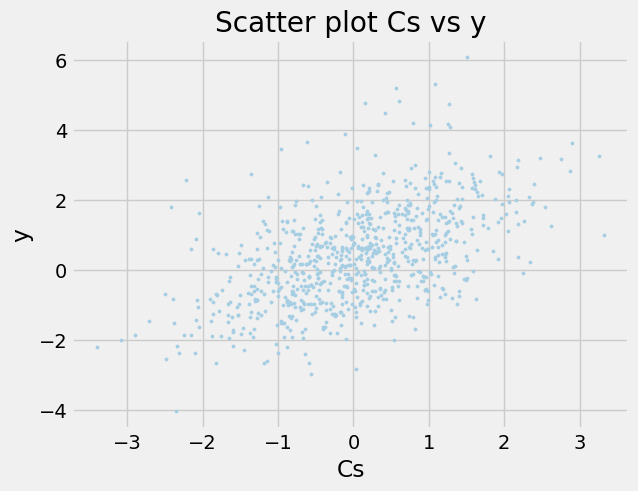

In [20]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y_dep_var", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [33]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y_dep_var"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_dep_var_ns"]
Y = gdf_output['Y_dep_var'].values

X_logit = sm.add_constant(X)

In [34]:
gdf_output4 = gdf_output.copy()
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'
df_encoded = pd.get_dummies(gdf_output4, columns=['treated'], dtype=int)
T_mult = df_encoded[['treated_inner_ring',
    'treated_outer_ring1',
    'treated_outer_ring2',
    'treated_outer_ring3',
    'treated_outer_ring4']].to_numpy()
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

##### Logit for T

In [35]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.368275
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  600
Model:                          Logit   Df Residuals:                      597
Method:                           MLE   Df Model:                            2
Date:                Sun, 24 May 2026   Pseudo R-squ.:                0.005287
Time:                        20:02:31   Log-Likelihood:                -220.97
converged:                       True   LL-Null:                       -222.14
Covariance Type:            nonrobust   LLR p-value:                    0.3090
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9832      0.126    -15.755      0.000      -2.230      -1.737
x1             0.0038      0.

##### Cross sectional linear difference in differences 

In [36]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Y_dep_var_ns   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     246.8
Date:                Sun, 24 May 2026   Prob (F-statistic):          4.41e-104
Time:                        20:02:42   Log-Likelihood:                -787.26
No. Observations:                 600   AIC:                             1583.
Df Residuals:                     596   BIC:                             1600.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2456      0.039      6.241      0.0

In [37]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Y_dep_var_ns   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     226.3
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.38e-98
Time:                        20:02:48   Log-Likelihood:                -801.38
No. Observations:                 600   AIC:                             1611.
Df Residuals:                     596   BIC:                             1628.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0953      0.049      1.945      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [ ]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y_dep_var",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

##### Basic causal forest

###### For T

In [ ]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

In [ ]:
ci_low_ate, ate, ci_high_ate

In [ ]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

###### For T tot

In [ ]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

#### Multiple T DML

In [ ]:
est = LinearDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)


In [ ]:
est.fit(Y, T_mult, X=X, 
        #W=W
        )

In [ ]:
te_pred = est.const_marginal_effect(X)
te_pred

In [ ]:
est2 = CausalForestDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

In [ ]:
te_pred2 = est2.const_marginal_effect(X)
te_pred2

#### S learner with multiple treatments

In [ ]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [ ]:
ate, lb, ub

In [ ]:
ITE_df['treated'].unique()

In [ ]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    series_of_interest = ITE_df[ITE_df['treated']==i][i]
    att = series_of_interest.mean()
    se_att = (series_of_interest).std(ddof=1) / np.sqrt(len(series_of_interest))
    ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
    print(i, 
          [ci_low_att, att, ci_high_att], 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

In [ ]:
ITE_df

In [ ]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

## Generating multiple df for simulations

### Data generation

#### Single test output

In [ ]:
# gdf_output = return_spatial_geo_df(n_x = 40,  
#     n_y = 20,    
#     spacing = 100, 

#     treated_scope_x_start = 10,
#     treated_scope_x_end = 24,
#     treated_scope_y_start = 7,
#     treated_scope_y_end = 13,

#     ATT_target = 1.5,

#     y_spatial_autocorelation_scope_x_start = 3,
#     y_spatial_autocorelation_scope_x_end = 25,
#     y_spatial_autocorelation_scope_y_start = 4,
#     y_spatial_autocorelation_scope_y_end = 11,

#     rho = 0.15,

#     spatial_confounder_scope_x_start = 12,
#     spatial_confounder_scope_x_end = 32,
#     spatial_confounder_scope_y_start = 2,
#     spatial_confounder_scope_y_end = 18,
    

#     lambda_cs = 0.2,
#     max_treatment_spillover_distance = 400,
#     understimated_treatment_spillover_distance=300,
#     overestimated_treatment_spillover_distance=500,
    
#     logistic_distance_decay = True,

#     nonspatial_confounders_contribution_to_Y=1.0,
#     spatial_confounder_contribution_to_Y=0.7,
    
#     epsilon_distribution_mean = 0.025,
#     epsilon_distribution_standard_error = 0.2)

#### Initial 15 samples for spatial predictors

In [ ]:
# list_of_rhos = []
# for i in np.arange(0.75, 0.000, -0.05):
#     list_of_rhos.append(i)
# len(list_of_rhos)

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = 0.15,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,
        

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=500,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}'] = single_gdf_output2

In [ ]:
#len(['gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'])

#### 16 additional samples for spatial predictors

In [ ]:
# list_of_rhos = []
# for i in np.arange(0.775, 0.000, -0.05):
#     list_of_rhos.append(i)
# len(list_of_rhos)

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = 0.15,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,
        

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=500,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}'] = single_gdf_output2

In [ ]:
#dict_of_output_gdf.keys()

#### 999 samples with spatial predictors and different rho

In [ ]:
# list_of_rhos2 = []
# for i in range(1, 1000, 1):
#     list_of_rhos2.append(i/1000)
# len(list_of_rhos2)

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos2:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = i,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=None,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
#                                                           # 'spill','T_tot',
#                         'distance_to_treatment',
#                         'decay','C3',
#                         'Cs','geometry',
#                         'propensity',
#                         'T_tot_cat_underestim']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}_nspred'] = single_gdf_output2

In [ ]:
# len(dict_of_output_gdf.keys())

#### 1000 samples without spatial predictors and different treated size

In [ ]:
# dict_of_combs = {}

# el3 = 5  

# for el1 in range(5, 20):          
#     el2 = el1 + 15                

#     for el4 in range(9, 15):      
#         for el5 in range(1, 17): 

#             y = ((el2 - el1) + 1) * ((el4 - el3) + 1) - (16 - el5)

#             # ograniczenie:
#             # jeśli y == 80, to el5 musi być równe 16
#             if y == 80 and el5 != 16:
#                 continue

#             key = f"s_{el1}_{el2}_{el3}_{el4}_{el5}_{y}"

#             dict_of_combs[key] = [el1, el2, el3, el4, el5]

In [ ]:
# for k in [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(65, 80))]:
#     dict_of_combs.pop(k, None)

In [ ]:
#len(dict_of_combs.keys())

1215

In [ ]:
#len([k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(80, 100))] + [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(0, 61))])

1215

In [7]:
# temp_list = ([k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(65, 99,5))  and dict_of_combs[k][1]==28] 
#     + [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(0, 61,5))  and dict_of_combs[k][1]==28])
# temp_list

In [ ]:
# dict_of_output_gdf = {}
# for i in temp_list:
#     single_gdf_output = return_spatial_geo_df(
        
#         n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = dict_of_combs[i][0],
#         treated_scope_x_end = dict_of_combs[i][1],
#         treated_scope_y_start = dict_of_combs[i][2],
#         treated_scope_y_end = dict_of_combs[i][3],
#         treated_last_row_length = dict_of_combs[i][4],


#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,


#         rho = 0.2,
#         spatial_confounder_scope_x_start = 0,
#         spatial_confounder_scope_x_end = 0,
#         spatial_confounder_scope_y_start = 0,
#         spatial_confounder_scope_y_end = 0,
        
#         lambda_cs = 0.0,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=None,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
#                                                           # 'spill','T_tot',
#                         'distance_to_treatment',
#                         'decay','C3',
#                         'Cs','geometry',
#                         'propensity',
#                         'T_tot_cat_underestim']).copy()
#     dict_of_output_gdf[i] = single_gdf_output2

In [8]:
#dict_of_output_gdf['s_13_28_5_9_16_80']

#### 1000 samples with different sample size

In [126]:
dict_of_combs = {

    'a': [12,10,4,6,4,5, None],
    'b': [16,10,4,7,4,5,None],
    'c': [20,10,4,8,4,5,None],
    'd': [20,12,4,7,4,6,None],
    'e': [20,14,4,7,4,7,2],
    
    'f': [20,16,4,7,4,7,None],
    'g': [20,18,4,8,4,7,3],
    'h': [20,20,4,8,4,7,None],
    'i': [22,20,4,9,4,7,4],
    'j': [24,20,4,9,4,7,6],
    'j': [26,20,4,10,4,7,5],

    'k': [28,20,4,11,4,7,4],
    'l': [30,20,4,13,4,6,None],
    'm': [32,20,4,13,4,7,2],
    'n': [34,20,4,13,4,7,4],
    'o': [36,20,4,13,4,7,6],

    'p': [38,20,4,13,4,7,8],
    'q': [40,20,4,13,4,7,10],
}

In [142]:
dict_of_output_gdf = {}
for i in dict_of_combs.keys():
    single_gdf_output = return_spatial_geo_df(
        
        n_x = dict_of_combs[i][0],  
        n_y = dict_of_combs[i][1],    
        spacing = 100, 

        treated_scope_x_start = dict_of_combs[i][2],
        treated_scope_x_end = dict_of_combs[i][3],
        treated_scope_y_start = dict_of_combs[i][4],
        treated_scope_y_end = dict_of_combs[i][5],
        treated_last_row_length = dict_of_combs[i][6],


        ATT_target = 1.5,

        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,


        rho = 0.2,
        spatial_confounder_scope_x_start = 0,
        spatial_confounder_scope_x_end = 0,
        spatial_confounder_scope_y_start = 0,
        spatial_confounder_scope_y_end = 0,
        
        lambda_cs = 0.0,
        max_treatment_spillover_distance = 300,
        understimated_treatment_spillover_distance=300,
        overestimated_treatment_spillover_distance=None,
        
        logistic_distance_decay = True,

        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
                                                          # 'spill','T_tot',
                        'distance_to_treatment',
                        'decay','C3',
                        'Cs','geometry',
                        'propensity',
                        'T_tot_cat_underestim']).copy()
    ik = str(dict_of_combs[i][0]*dict_of_combs[i][1])
    dict_of_output_gdf[i] = single_gdf_output2

In [143]:
dict_of_output_gdf.keys()

dict_keys(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q'])

# Data saving

In [144]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [145]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data_ysamp_size.sqlite')
cursor = conn.cursor()

In [146]:
repo_path_r_string

'C:\\Users\\andre\\Desktop\\IDS\\02_VS_code\\03_comparing_causal_ML_models_with_spatial_effects'

In [147]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_sql(
    k,
    conn,
    if_exists="replace",
    index=False
)


In [ ]:
# sqlite_path = repo_path_r_string + r"\03_simulated_data\simulated_data.sqlite"

# for k, gdf in dict_of_output_gdf.items():

#     gdf.to_file(
#         sqlite_path,
#         layer=k,
#         driver="SQLite"
#     )

In [148]:
conn.close()